In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Exemple : embeddings sauvegardés dans un fichier .npy
embeddings = np.load("../data/embeddings.npy")   # shape (N, D)
labels = np.load("../data/labels.npy")           # shape (N,)

# Si tu as un parquet :
# df = pd.read_parquet("data/embeddings.parquet")
# embeddings = np.vstack(df["embedding"].values)
# labels = df["label"].values

print("Embeddings shape:", embeddings.shape)
print("Labels shape:", labels.shape)

Embeddings shape: (8001, 1536)
Labels shape: (8001,)


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

In [4]:
unique_classes = np.unique(labels)
clusters = {}

for cls in unique_classes:
    idx = np.where(labels == cls)[0]
    X_cls = embeddings_scaled[idx]

    # KMeans avec 1 cluster (centroïde principal)
    kmeans = KMeans(n_clusters=4, random_state=42)
    kmeans.fit(X_cls)

    centroid = kmeans.cluster_centers_[0]
    distances = pairwise_distances(X_cls, [centroid]).flatten()

    clusters[cls] = {
        "centroid": centroid,
        "distances": distances,
        "threshold": np.percentile(distances, 99) * 1.2,  # seuil automatique
        "indices": idx
    }

    print(f"{cls}: threshold={clusters[cls]['threshold']:.4f}")

0: threshold=65.4501
1: threshold=66.9308
2: threshold=86.5703
3: threshold=84.5263
4: threshold=70.4727
5: threshold=78.3555
6: threshold=87.9111
7: threshold=42.5548
8: threshold=67.7724
9: threshold=79.7772
10: threshold=42.3085
11: threshold=71.3131
12: threshold=79.9851
13: threshold=62.5916
14: threshold=94.3158
15: threshold=73.4609
16: threshold=76.9033
17: threshold=63.1716
18: threshold=78.8727
19: threshold=71.0301
20: threshold=69.5202
21: threshold=77.7252
22: threshold=77.0382
23: threshold=81.7534
24: threshold=77.7859
25: threshold=76.7185
26: threshold=78.5491
27: threshold=73.1393
28: threshold=79.3494
29: threshold=75.4745
30: threshold=97.3433
31: threshold=74.6045
32: threshold=60.7519
33: threshold=82.8590
34: threshold=71.7852


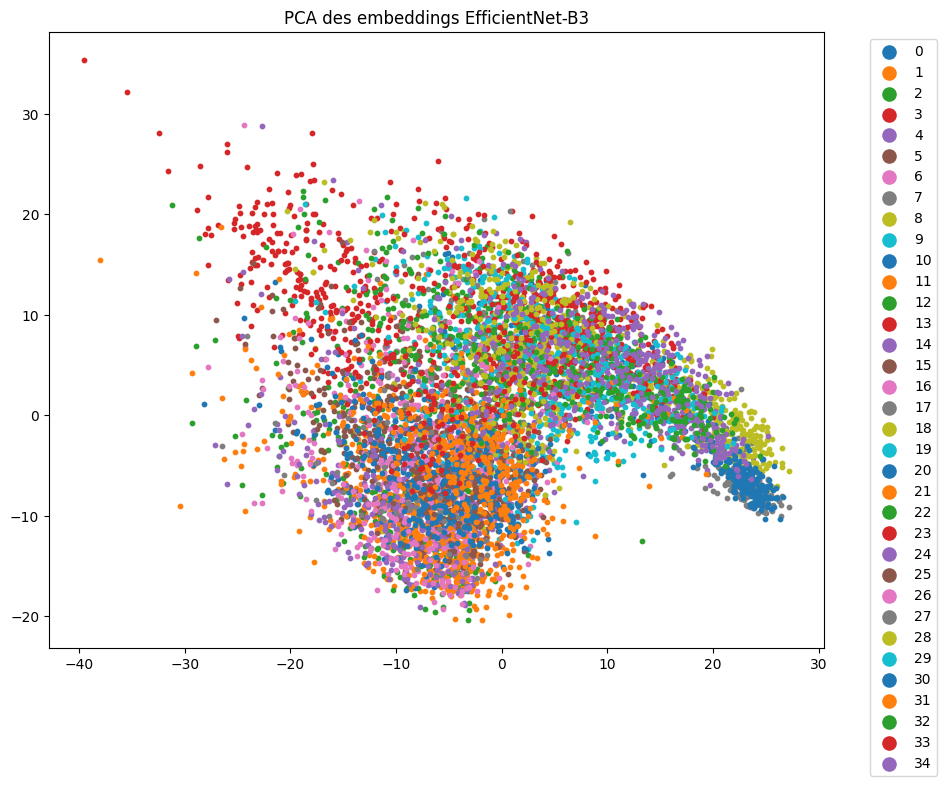

In [5]:
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings_scaled)

plt.figure(figsize=(10, 8))
for cls in unique_classes:
    idx = np.where(labels == cls)[0]
    plt.scatter(emb_2d[idx, 0], emb_2d[idx, 1], s=10, label=cls)

plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("PCA des embeddings EfficientNet-B3")
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    embeddings_scaled, labels, test_size=0.2, random_state=42, stratify=labels
)

model_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(unique_classes),
    eval_metric="mlogloss",
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9
)

model_xgb.fit(X_train, y_train)

y_pred = model_xgb.predict(X_test)
print(classification_report(y_test, y_pred))

KeyboardInterrupt: 

In [ ]:
model_xgb.save_model("../backend/app/models_flowers_fruits/xgboost_model.json")

In [ ]:
with open("../backend/app/models_flowers_fruits/unique_classes.txt", "w") as f:
    for cls in unique_classes:
        f.write(f"{cls}\n")
with open("../backend/app/models_flowers_fruits/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [ ]:
def filter_image(embedding, clusters, model_xgb, threshold_factor=1.2):
    # 1. Prédiction XGBoost
    proba = model_xgb.predict_proba([embedding])[0]
    pred_class = unique_classes[np.argmax(proba)]
    confidence = np.max(proba)

    # 2. Distance au centroïde
    centroid = clusters[pred_class]["centroid"]
    dist = np.linalg.norm(embeddings_scaled - centroid)

    # 3. Seuil dynamique
    threshold = clusters[pred_class]["threshold"] * threshold_factor

    # 4. Décision
    is_valid = (confidence > 0.1) and (dist < threshold)

    return {
        "pred_class": pred_class,
        "confidence": confidence,
        "distance": dist,
        "threshold": threshold,
        "is_valid": is_valid
    }

In [ ]:
from PIL import Image
import torch
from torchvision import transforms
from efficientnet_pytorch import EfficientNet

# Charger EfficientNet-B3
model = EfficientNet.from_pretrained('efficientnet-b3')
model.eval()

# Transformations
transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
])

def get_embedding(img_path):
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0)
    with torch.no_grad():
        feat = model.extract_features(x)
        feat = torch.nn.functional.adaptive_avg_pool2d(feat, 1).flatten()
    return feat.numpy()

# Exemple
for images in os.listdir("../data/dataset_flowers/hellebore/")[:50]:  # tester sur les 5 premières images
    embedding = get_embedding(f"../data/dataset_flowers/hellebore/{images}")
    embeddings_scaled = scaler.transform([embedding])  # appliquer le même scaler
    result = filter_image(embeddings_scaled[0], clusters, model_xgb)
    print(result)